In [10]:
import pandas as pd
import numpy as np

caminho_arquivo = '../data/raw/TrafficTwoMonth.xlsx'

try:
    # 1. Carrega o arquivo Excel
    df_raw = pd.read_excel(caminho_arquivo)
    
    # 2. Pega o nome da coluna única (que contém os cabeçalhos separados por vírgula)
    nome_coluna_unica = df_raw.columns[0]
    
    # 3. Divide a coluna única em 9 colunas separadas usando a vírgula como delimitador
    df = df_raw[nome_coluna_unica].str.split(',', expand=True)
    
    # 4. Define os nomes das colunas a partir do cabeçalho original
    df.columns = nome_coluna_unica.split(',')
    
    # 5. Converte as colunas numéricas de texto para número (int)
    colunas_numericas = ['CarCount', 'BikeCount', 'BusCount', 'TruckCount', 'Total']
    for col in colunas_numericas:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
    print("✅ Sucesso! Colunas divididas e convertidas corretamente!\n")
    print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.\n")
    
    # Exibe as primeiras 5 linhas organizadas em tabela
    display(df.head())
    
    # Exibe as informações finais das colunas
    print("\n--- INFORMAÇÕES DAS COLUNAS ---")
    df.info()

except Exception as e:
    print(f"❌ Ocorreu um erro ao processar as colunas: {e}")

✅ Sucesso! Colunas divididas e convertidas corretamente!

Dimensões do dataset: 5952 linhas e 9 colunas.



,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,13,2,2,24,41,normal
1,12:15:00 AM,10,Tuesday,14,1,1,36,52,normal
2,12:30:00 AM,10,Tuesday,10,2,2,32,46,normal
3,12:45:00 AM,10,Tuesday,10,2,2,36,50,normal
4,1:00:00 AM,10,Tuesday,11,2,1,34,48,normal



--- INFORMAÇÕES DAS COLUNAS ---
<class 'pandas.DataFrame'>
RangeIndex: 5952 entries, 0 to 5951
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Time               5952 non-null   str  
 1   Date               5952 non-null   str  
 2   Day of the week    5952 non-null   str  
 3   CarCount           5952 non-null   int64
 4   BikeCount          5952 non-null   int64
 5   BusCount           5952 non-null   int64
 6   TruckCount         5952 non-null   int64
 7   Total              5952 non-null   int64
 8   Traffic Situation  5952 non-null   str  
dtypes: int64(5), str(4)
memory usage: 418.6 KB


In [11]:
# 1. Estatísticas descritivas do volume de veículos
print("=== RESUMO ESTATÍSTICO DOS VEÍCULOS ===")
display(df[['CarCount', 'BikeCount', 'BusCount', 'TruckCount', 'Total']].describe())

# 2. Distribuição das situações de trânsito
print("\n=== DISTRIBUIÇÃO DA SITUAÇÃO DO TRÂNSITO ===")
display(df['Traffic Situation'].value_counts(normalize=True) * 100)

# 3. Média de veículos por dia da semana
print("\n=== MÉDIA DE VEÍCULOS POR DIA DA SEMANA ===")
media_dia_semana = df.groupby('Day of the week')['Total'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
display(media_dia_semana)

=== RESUMO ESTATÍSTICO DOS VEÍCULOS ===


,CarCount,BikeCount,BusCount,TruckCount,Total
count,5952.000000,5952.000000,5952.000000,5952.000000,5952.000000
mean,65.440692,12.161458,12.912970,18.646337,109.161458
std,44.749335,11.537944,12.497736,10.973139,55.996312
min,5.000000,0.000000,0.000000,0.000000,21.000000
25%,18.750000,3.000000,2.000000,10.000000,54.000000
50%,62.000000,9.000000,10.000000,18.000000,104.000000
75%,103.000000,19.000000,20.000000,27.000000,153.000000
max,180.000000,70.000000,50.000000,60.000000,279.000000



=== DISTRIBUIÇÃO DA SITUAÇÃO DO TRÂNSITO ===


Traffic Situation
normal    60.651882
heavy     19.102823
low       14.012097
high       6.233199
Name: proportion, dtype: float64


=== MÉDIA DE VEÍCULOS POR DIA DA SEMANA ===


Day of the week
Monday       108.822917
Tuesday      109.252083
Wednesday    110.237500
Thursday     109.452083
Friday       106.283854
Saturday     110.080729
Sunday       109.636719
Name: Total, dtype: float64

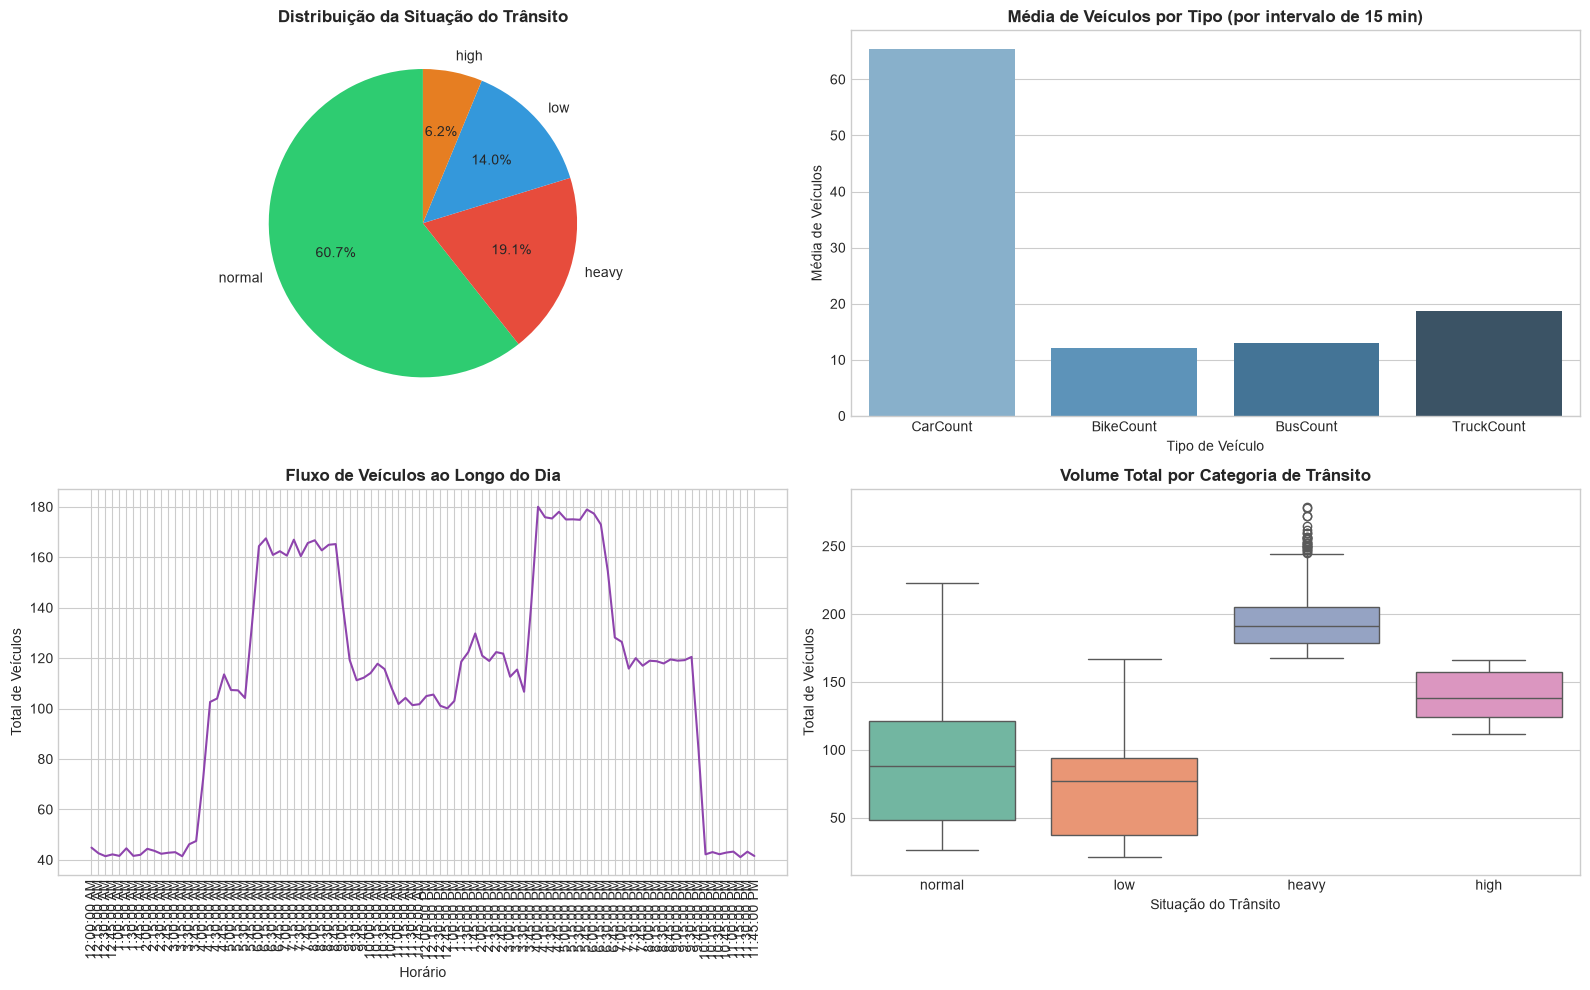

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Oculta avisos de deprecacao no Jupyter

# Configuração do estilo visual dos gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Gráfico de Rosca: Distribuição da Situação do Trânsito
traffic_counts = df['Traffic Situation'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db', '#e67e22']
axes[0, 0].pie(traffic_counts, labels=traffic_counts.index, autopct='%1.1f%%', startangle=90, colors=colors)
axes[0, 0].set_title('Distribuição da Situação do Trânsito', fontsize=12, fontweight='bold')

# 2. Gráfico de Barras: Média de Cada Tipo de Veículo (Sintaxe atualizada com hue)
media_veiculos = df[['CarCount', 'BikeCount', 'BusCount', 'TruckCount']].mean().reset_index()
media_veiculos.columns = ['Tipo', 'Media']
sns.barplot(data=media_veiculos, x='Tipo', y='Media', hue='Tipo', ax=axes[0, 1], palette='Blues_d', legend=False)
axes[0, 1].set_title('Média de Veículos por Tipo (por intervalo de 15 min)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Média de Veículos')
axes[0, 1].set_xlabel('Tipo de Veículo')

# 3. Gráfico de Linha: Fluxo Total Médio por Horário do Dia
sns.lineplot(data=df, x='Time', y='Total', ax=axes[1, 0], color='#8e44ad', errorbar=None)
axes[1, 0].set_title('Fluxo de Veículos ao Longo do Dia', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Horário')
axes[1, 0].set_ylabel('Total de Veículos')
axes[1, 0].tick_params(axis='x', rotation=90)

# 4. Boxplot: Volume Total por Categoria (Sintaxe atualizada com hue)
sns.boxplot(data=df, x='Traffic Situation', y='Total', hue='Traffic Situation', ax=axes[1, 1], palette='Set2', legend=False)
axes[1, 1].set_title('Volume Total por Categoria de Trânsito', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Situação do Trânsito')
axes[1, 1].set_ylabel('Total de Veículos')

plt.tight_layout()
plt.show()

In [14]:
import os

# Garante que a pasta de dados processados existe
os.makedirs('../data/processed', exist_ok=True)

# 1. Salva em CSV limpo
caminho_csv = '../data/processed/traffic_clean.csv'
df.to_csv(caminho_csv, index=False, encoding='utf-8')

print(f"✅ Arquivo processado salvo com sucesso em: {caminho_csv}")

✅ Arquivo processado salvo com sucesso em: ../data/processed/traffic_clean.csv


In [15]:
import pandas as pd
from sqlalchemy import create_engine, text

# 1. Carregar o CSV limpo da pasta processed
df_clean = pd.read_csv('../data/processed/traffic_clean.csv')

# 2. Mapear e renomear as colunas para o padrão do nosso schema SQL
colunas_sql = {
    'Time': 'horario',
    'Date': 'dia_mes',
    'Day of the week': 'dia_semana',
    'CarCount': 'qtd_carros',
    'BikeCount': 'qtd_motos',
    'BusCount': 'qtd_onibus',
    'TruckCount': 'qtd_caminhoes',
    'Total': 'qtd_total',
    'Traffic Situation': 'situacao_trafego'
}

df_sql = df_clean.rename(columns=colunas_sql)

# 3. Criar a conexão com o banco de dados SQLite (salvo na pasta data/traffic_database.db)
engine = create_engine('sqlite:///../data/traffic_database.db')

# 4. Inserir os dados na tabela tb_trafego_veiculos
df_sql.to_sql('tb_trafego_veiculos', con=engine, if_exists='replace', index_label='id_registro')

print("✅ Banco de Dados criado e 5.952 registros inseridos com sucesso em 'data/traffic_database.db'!")

✅ Banco de Dados criado e 5.952 registros inseridos com sucesso em 'data/traffic_database.db'!


In [16]:
# Consulta SQL de teste: Top 5 horários com maior volume médio de veículos
query = """
SELECT 
    horario,
    ROUND(AVG(qtd_total), 2) AS media_veiculos,
    MAX(qtd_total) AS max_veiculos
FROM tb_trafego_veiculos
GROUP BY horario
ORDER BY media_veiculos DESC
LIMIT 5;
"""

with engine.connect() as conexao:
    resultado = pd.read_sql(text(query), conexao)

display(resultado)

,horario,media_veiculos,max_veiculos
0,4:00:00 PM,180.02,223
1,5:45:00 PM,178.92,237
2,4:45:00 PM,178.02,239
3,6:00:00 PM,177.32,234
4,4:15:00 PM,175.85,223
